# metabeta — priors and prior sensitivity

This notebook demonstrates how to control and inspect priors in **metabeta**:

1. **Simulate** a Bernoulli dataset from a known prior — so we know the ground truth.
2. **Specify explicit priors** and run a batched prior-sensitivity analysis in a single `sample()` call.
3. **Plot posterior parameters** with prior overlays for each prior variant.

> **Setup (run once):** The cell below assembles a joint checkpoint from local training runs.
> In a future release, pre-trained weights will be downloaded automatically on first use.

In [1]:
# Run this cell once to build the joint checkpoint
from pathlib import Path
from metabeta.utils.api import joinCheckpoints
from metabeta.utils.experiments import CHECKPOINT_DIR

OUTPUT_PATH = Path('/tmp/joint_bernoulli_v1.pt')

if not OUTPUT_PATH.exists():
    ckpt_dir = CHECKPOINT_DIR
    checkpoints = [
        ckpt_dir / 'data=small-b-mixed_model=large_seed=2',
        ckpt_dir / 'data=small-b-mixed_model=large_seed=3',
        ckpt_dir / 'data=small-b-mixed_model=large_seed=4',
        ckpt_dir / 'data=small-b-mixed_model=large_seed=5',
    ]
    joinCheckpoints(
        checkpoints,
        output_path=OUTPUT_PATH,
        ids=['b_s2', 'b_s3', 'b_s4', 'b_s5'],
    )
    print(f'Joint checkpoint saved to {OUTPUT_PATH}')
else:
    print(f'Joint checkpoint already exists at {OUTPUT_PATH}')

Joint checkpoint already exists at /tmp/joint_bernoulli_v1.pt


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from metabeta.models.api import Api

mb = Api('/tmp/joint_bernoulli_v1.pt', device='cpu')

## 1. Simulate a Bernoulli dataset

Rather than loading a fixed dataset, we generate data from a known prior. This allows us to check
how well the posterior recovers the true parameters and how prior choice affects inference.

We define the prior hyperparameters explicitly — the same values are later reused as the
`generative` prior in the sensitivity analysis, so the two are guaranteed to match.

The model has **4 fixed effects** (intercept + 3 predictors) and **2 correlated random effects**
(random intercept + random slope on X1).

In [3]:
from metabeta.simulation import Prior, Scammer
from metabeta.simulation.simulator import Simulator

seed = 8
rng = np.random.default_rng(seed)

d = 4      # fixed effects: intercept + X1 + X2 + X3
q = 2      # random effects: intercept + X1 slope
m = 30     # number of groups
formula = 'y ~ X1 + X2 + X3 + (1 + X1 | group)'

# Explicit prior hyperparameters — these same values are reused as the
# 'generative' prior in the sensitivity analysis below.
hparams = {
    'likelihood_family': np.array(1),            # Bernoulli (logit link)
    'nu_ffx':            np.zeros(d),             # zero-centered (standardized scale)
    'tau_ffx':           np.array([1.0, 0.8, 0.8, 0.8]),   # per-term scale
    'tau_rfx':           np.array([0.6, 0.6]),              # per-rfx SD scale
    'eta_rfx':           np.array(1.5),           # LKJ concentration
    'family_ffx':        np.array(0),             # Normal
    'family_sigma_rfx':  np.array(0),             # HalfNormal
}

prior = Prior(rng, hparams)
scammer = Scammer(rng)
ns = rng.integers(8, 20, size=m)
sim = Simulator(rng, prior, scammer, ns)
ds = sim.sample()

# build DataFrame (drop intercept column X[:, 0] == 1)
df = pd.DataFrame(ds['X'][:, 1:], columns=['X1', 'X2', 'X3'])
df['y'] = ds['y'].astype(int)
df['group'] = ds['groups']

print(f'Dataset: n={len(df)} observations, m={df["group"].nunique()} groups')
print(f'Outcome prevalence: {df["y"].mean():.2%}')
print()
print('True parameters:')
print(f'  fixed effects  (intercept, X1, X2, X3):  {np.round(ds["ffx"], 3)}')
print(f'  sigmas:                                  {np.round(ds["sigma_rfx"], 3)}')
print(f'  corr(intercept, X1):                     {ds["corr_rfx"][1, 0]:.3f}')

Dataset: n=391 observations, m=30 groups
Outcome prevalence: 52.69%

True parameters:
  fixed effects  (intercept, X1, X2, X3):  [ 0.258 -1.312  0.288 -0.095]
  sigmas:                                  [0.144 0.093]
  corr(intercept, X1):                     -0.117


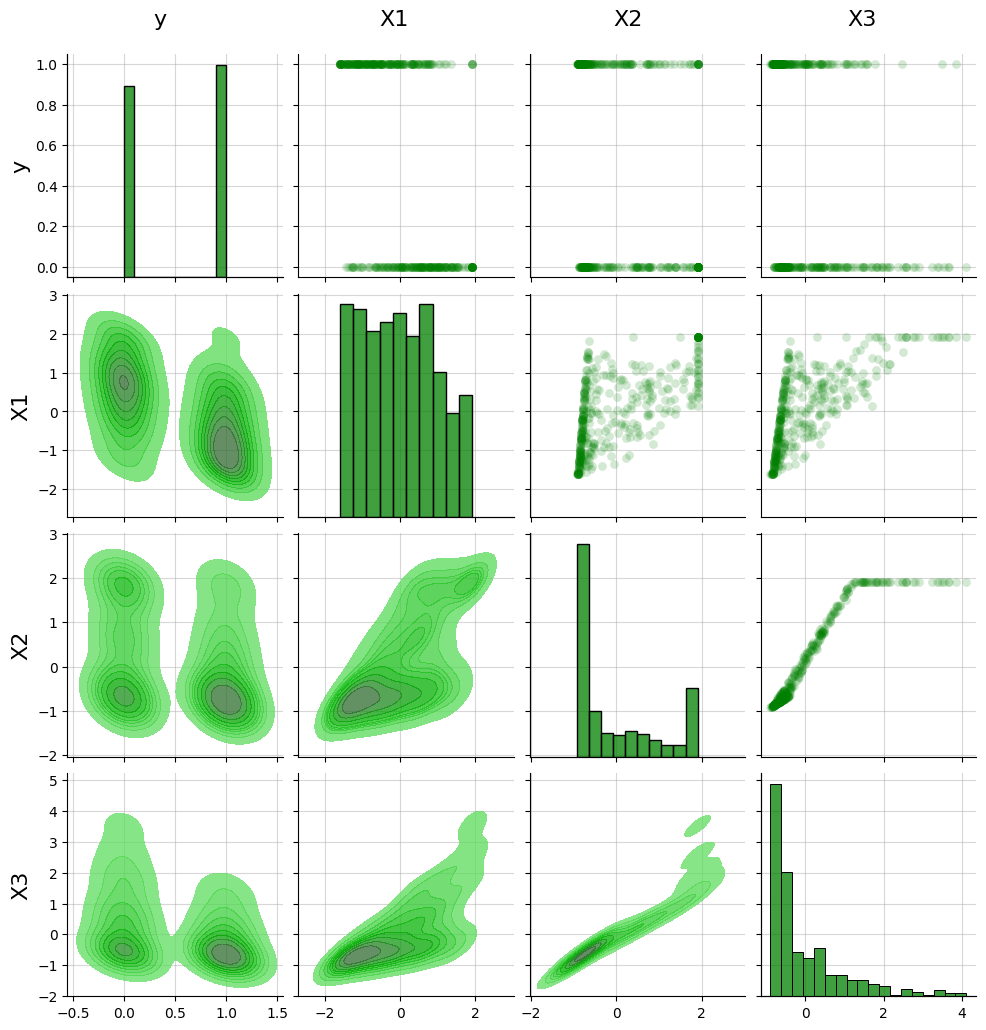

In [4]:
from metabeta.plotting import plotDataset

g = plotDataset(df[['y', 'X1', 'X2', 'X3']])
plt.show()

## 2. Prior sensitivity analysis

We compare three prior specifications in a **single `sample()` call** by passing a named
dictionary.  metabeta stacks them into a batch and runs all three in one forward pass.

| Variant | Description |
|---|---|
| `default` | Model's learned default — weakly informative, bambi-style |
| `generative` | The true generative prior (same `tau` used to simulate the data) |
| `skeptical` | Very tight prior that shrinks all effects toward zero |

**Default priors.** When no prior is specified, metabeta applies scales it learned during
training to approximate bambi's weakly informative defaults: for a Bernoulli GLMM on
standardised predictors these are Intercept ~ N(0, 1.5), slopes ~ N(0, 1),
σ_rfx ~ HN(2.5), and Corr ~ LKJ(1).  They are broad enough that the likelihood dominates
in most practical settings.

Priors use the **term-based schema**:
- `fixed` maps each formula term to `{"tau": value}` and optionally `{"nu": value}` specs
- `random_sd` maps each random-effect SD term to a `{"tau": value}` spec
- `corr_rfx` takes `{"eta": value}` for the LKJ concentration

In [ ]:
generative = {
    'fixed': {
        'Intercept': {'tau': float(hparams['tau_ffx'][0])},
        'X1':        {'tau': float(hparams['tau_ffx'][1])},
        'X2':        {'tau': float(hparams['tau_ffx'][2])},
        'X3':        {'tau': float(hparams['tau_ffx'][3])},
    },
    'random_sd': {
        'Intercept': {'tau': float(hparams['tau_rfx'][0])},
        'X1':        {'tau': float(hparams['tau_rfx'][1])},
    },
    'corr_rfx': {'eta': float(hparams['eta_rfx'])},
}

skeptical = {
    'fixed': {
        'Intercept': {'tau': 0.5},
        'X1':        {'tau': 0.3},
        'X2':        {'tau': 0.3},
        'X3':        {'tau': 0.3},
    },
    'random_sd': {
        'Intercept': {'tau': 0.3},
        'X1':        {'tau': 0.3},
    },
    'corr_rfx': {'eta': 2.0},
}

priors = {'default': None, 'generative': generative, 'skeptical': skeptical}

In [6]:
result = mb.sample(
    df,
    formula=formula,
    priors=priors,
    n_samples=1000,
    diagnostics=True,
)

## 3. Posterior summaries

In [7]:
for i, name in enumerate(priors):
    print(f'\n{"="*60}')
    print(f'Prior: {name}')
    print('='*60)
    print(mb.posteriorSummary(result, batch_index=i))


Prior: default
Formula:  y ~ X1 + X2 + X3 + (1 + X1 | group)
n = 391   m = 30
Scale:    standardized covariates
Priors:
  Intercept ~ N(0, 1.5)
  x1 ~ N(0, 1)
  x2 ~ N(0, 1)
  x3 ~ N(0, 1)
  σ_Intercept ~ HN(2.5)
  σ_x1 ~ HN(2.5)
  Corr ~ LKJ(1)

Fixed Effects:
|           |   Mean |    SD |   2.5% |   50.0% |   97.5% |   P(>0) |   Contr. |
|-----------|--------|-------|--------|---------|---------|---------|----------|
| Intercept |  0.144 | 0.157 | -0.180 |   0.145 |   0.459 |   0.840 |    0.989 |
| x1        | -1.558 | 0.235 | -2.026 |  -1.551 |  -1.131 |   0.000 |    0.945 |
| x2        | -0.032 | 0.365 | -0.783 |  -0.023 |   0.671 |   0.475 |    0.867 |
| x3        |  0.248 | 0.471 | -0.647 |   0.246 |   1.216 |   0.711 |    0.778 |

Standard Deviations:
|           |   Mean |    SD |   2.5% |   50.0% |   97.5% |
|-----------|--------|-------|--------|---------|---------|
| Intercept |  0.316 | 0.211 |  0.012 |   0.295 |   0.763 |
| x1        |  0.239 | 0.203 |  0.007 |   0.195 |

## 4. Posterior parameter plots with prior overlays

The pair grids show:
- **Green**: marginal posterior KDE / 2D contours
- **Blue**: analytical prior PDF
- **Purple dashed**: ground-truth parameter values

The bottom-right column shows the correlation parameter ρ between the random intercept and
random X1 slope — included automatically when `q ≥ 2` and the model used a LKJ prior.

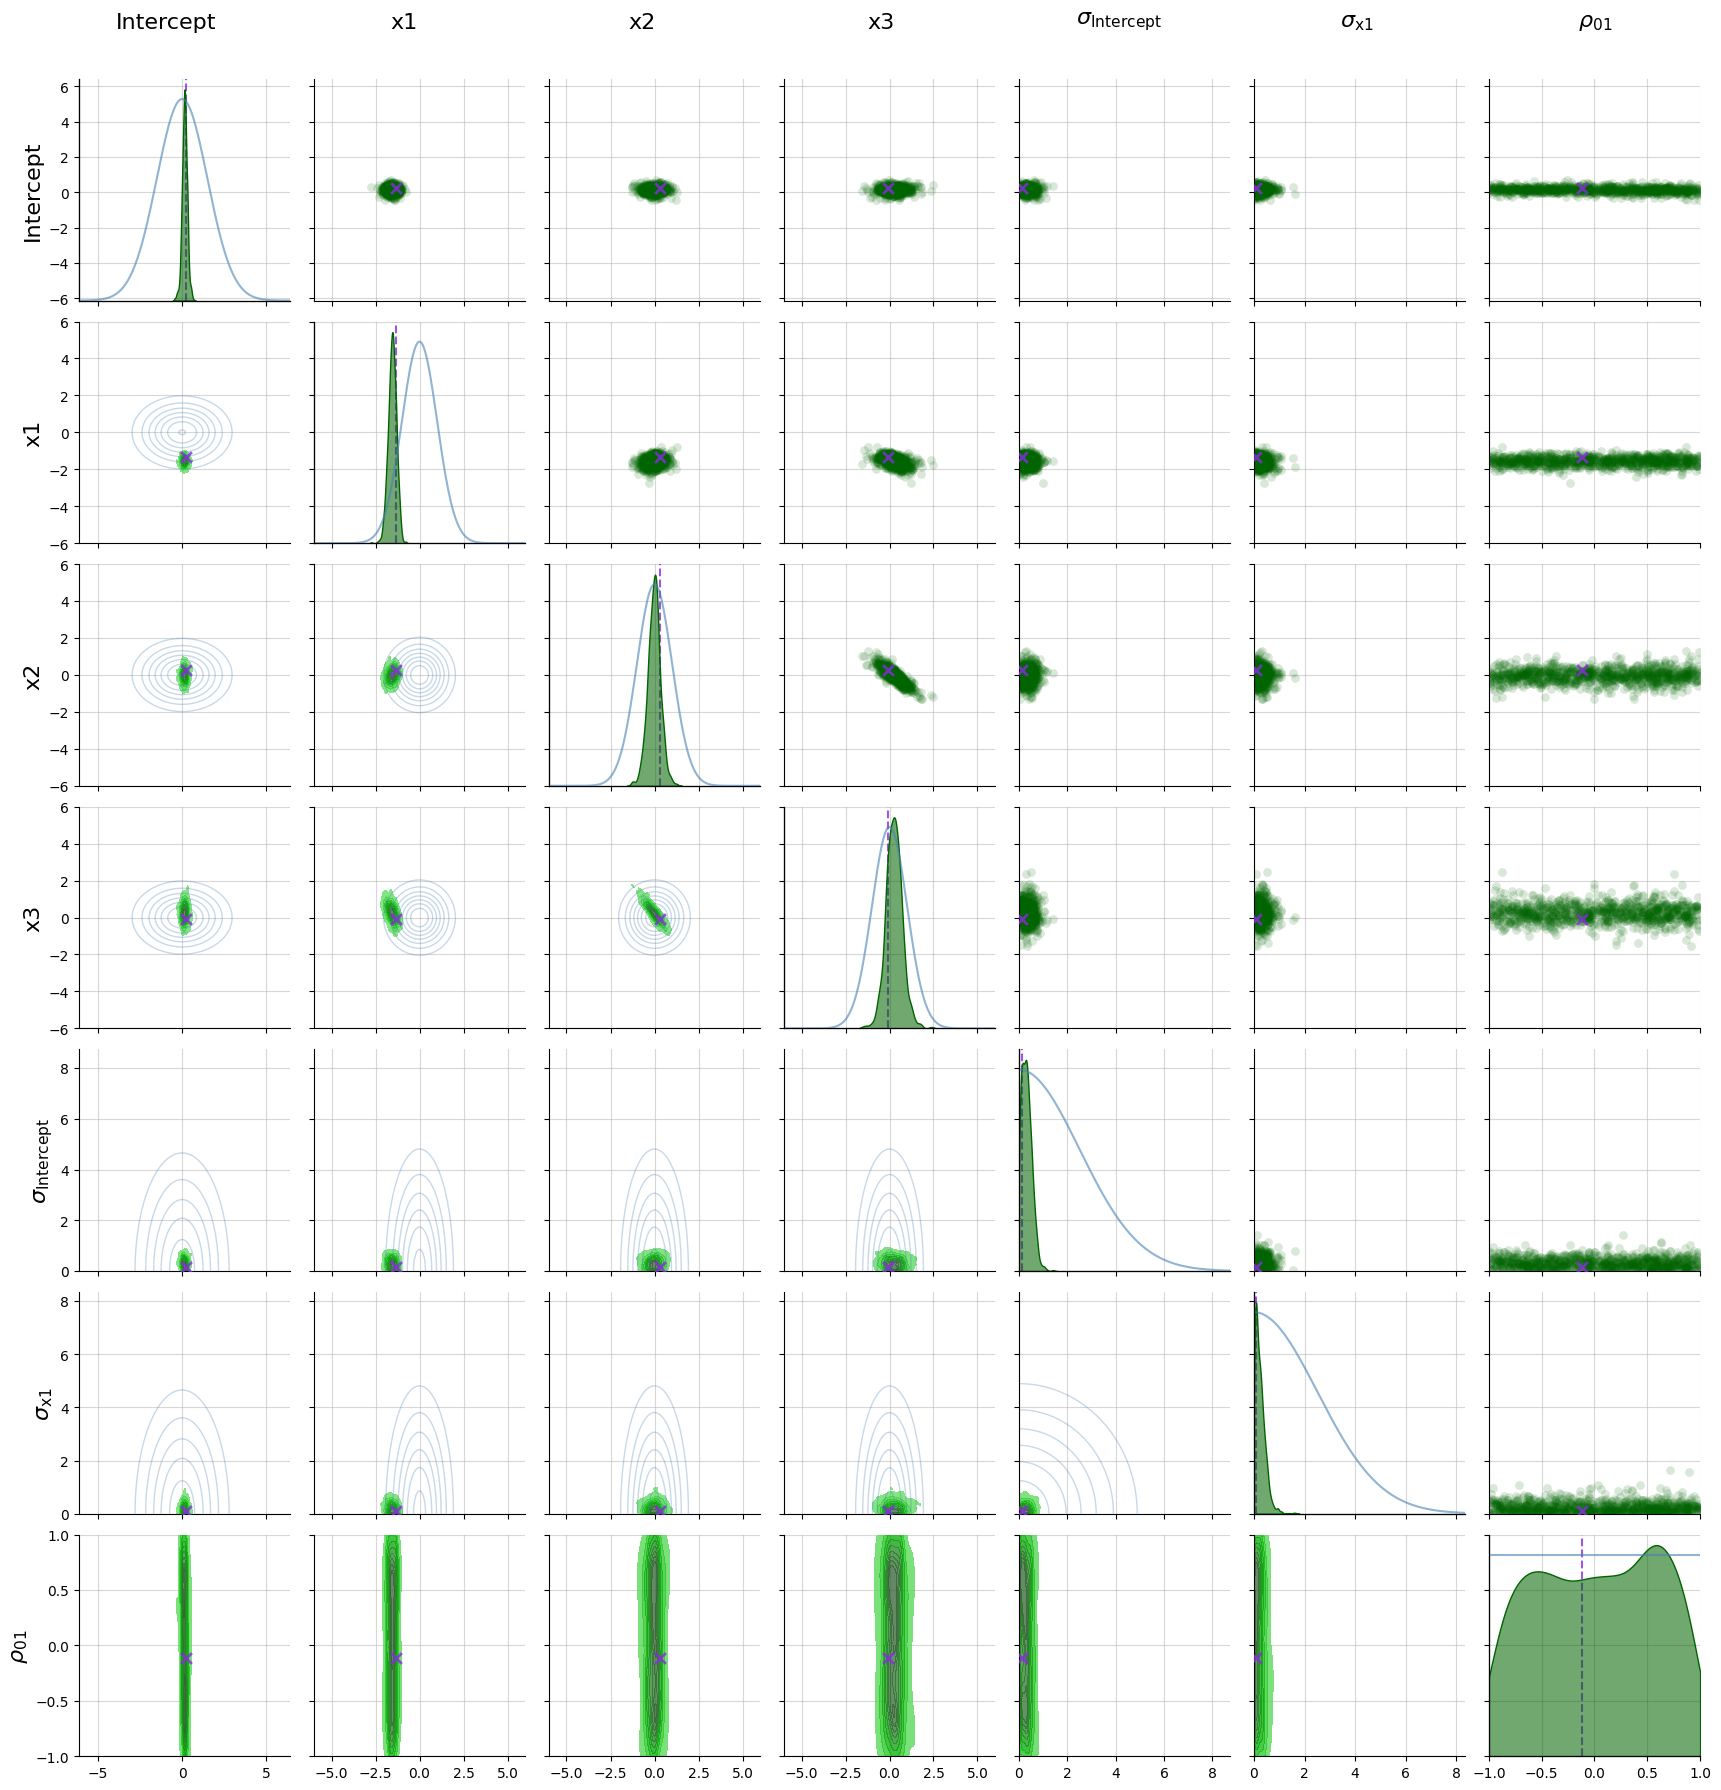

In [8]:
truth = np.concatenate([ds['ffx'], ds['sigma_rfx'], [ds['corr_rfx'][1, 0]]])

g = mb.plotParameters(result, index=0, with_prior=True, truth=truth)  # default
plt.show()

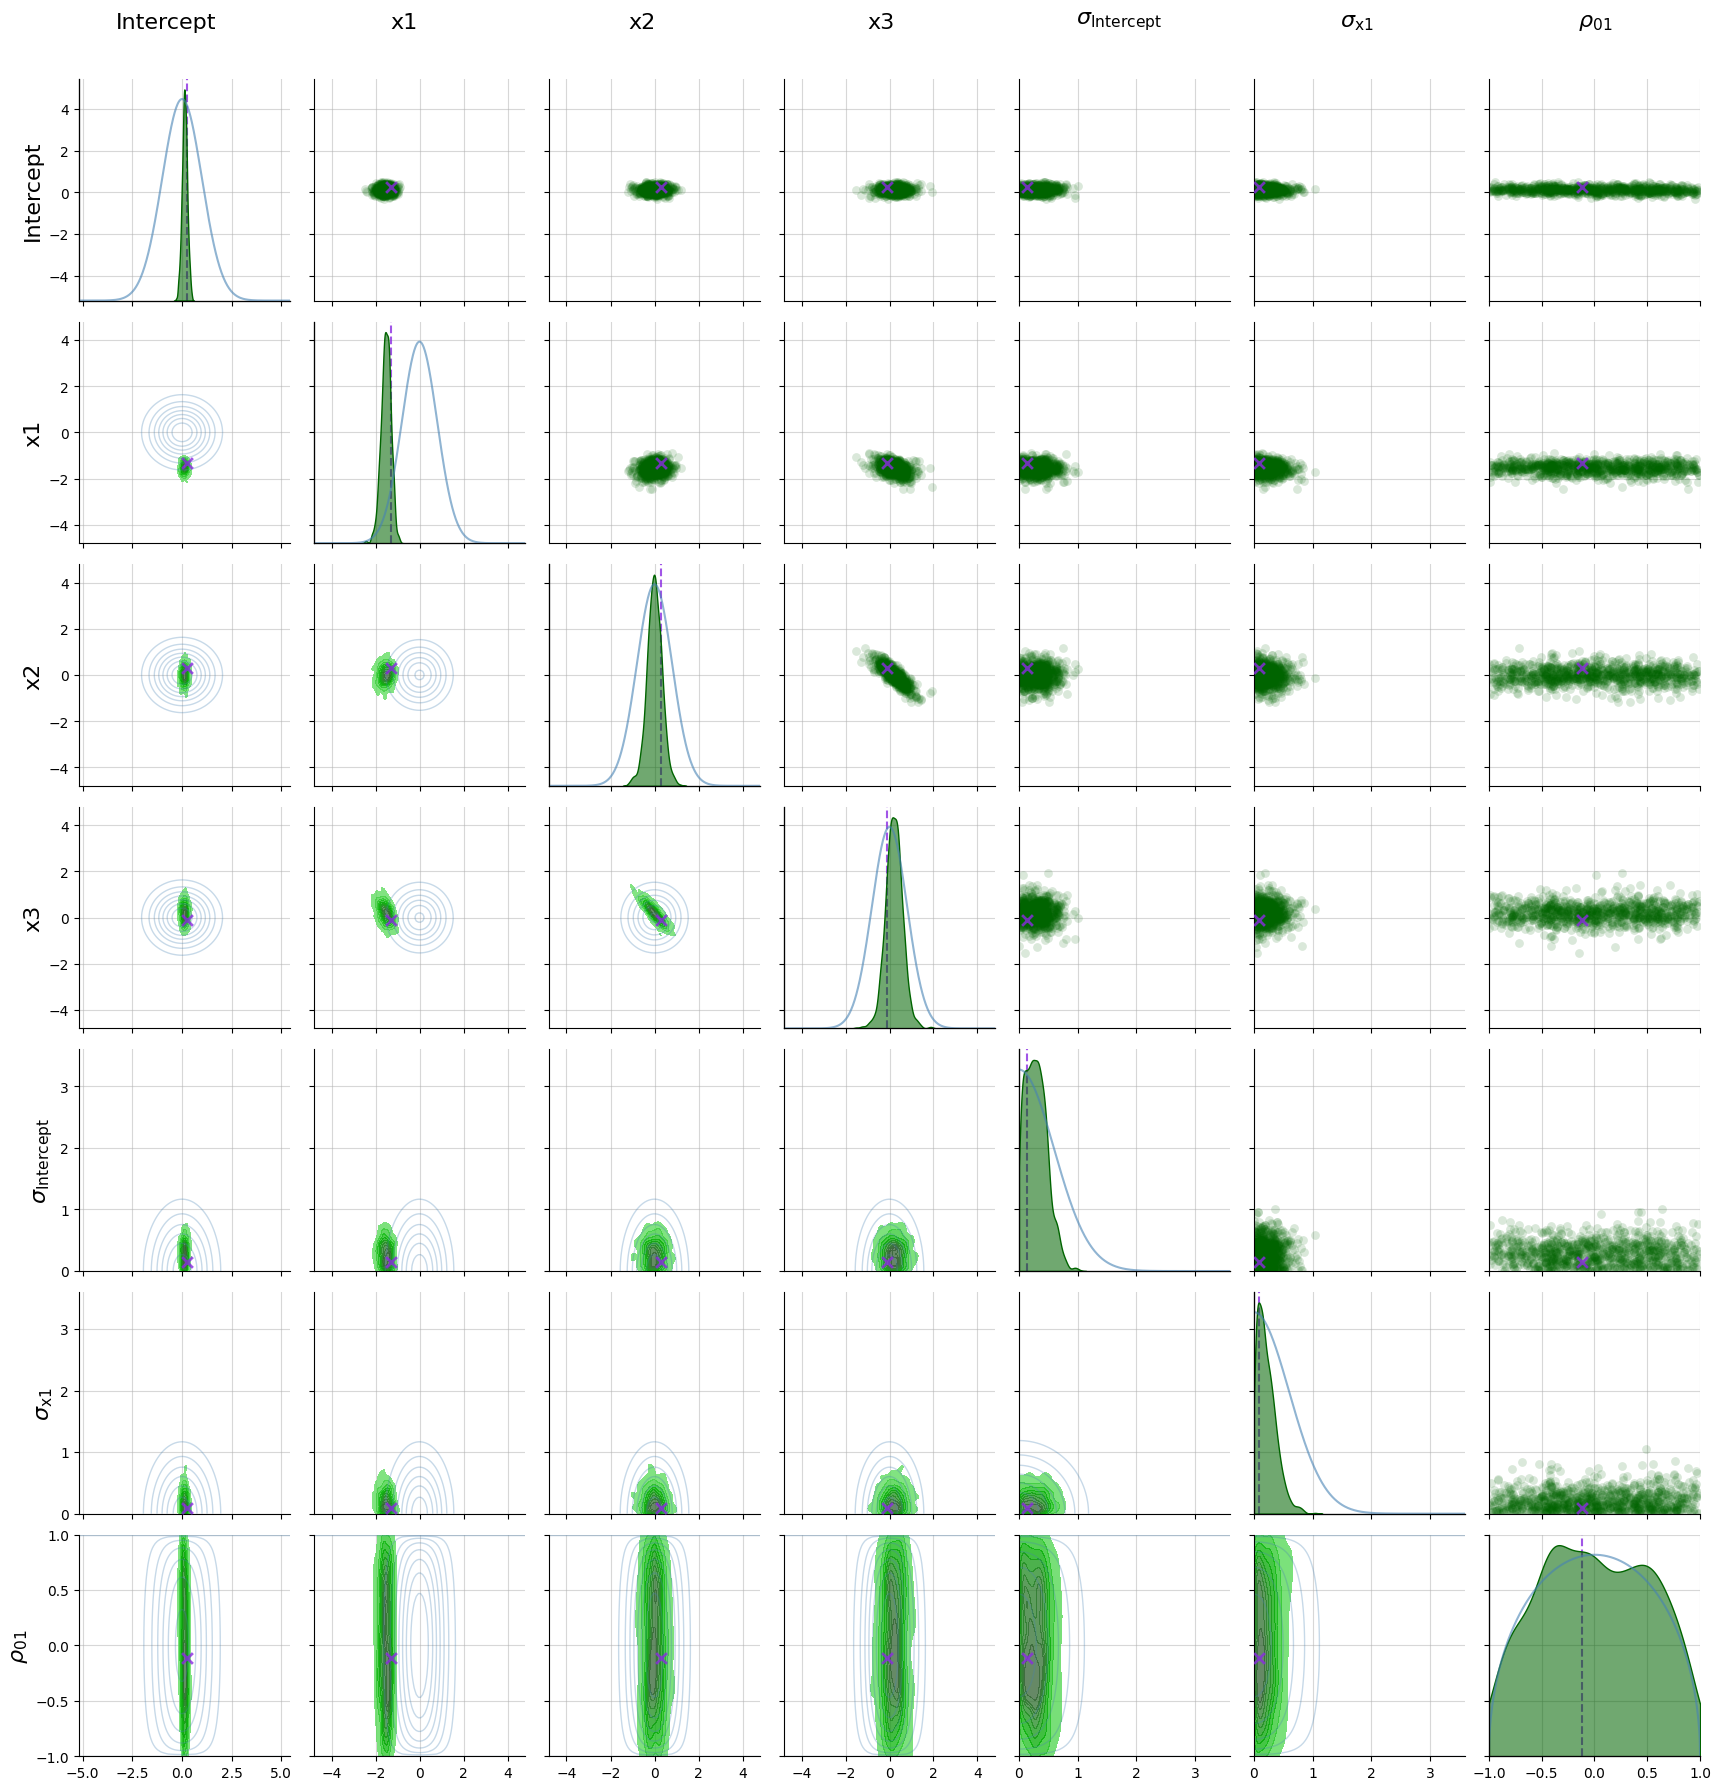

In [9]:
g = mb.plotParameters(result, index=1, with_prior=True, truth=truth)  # generative
plt.show()

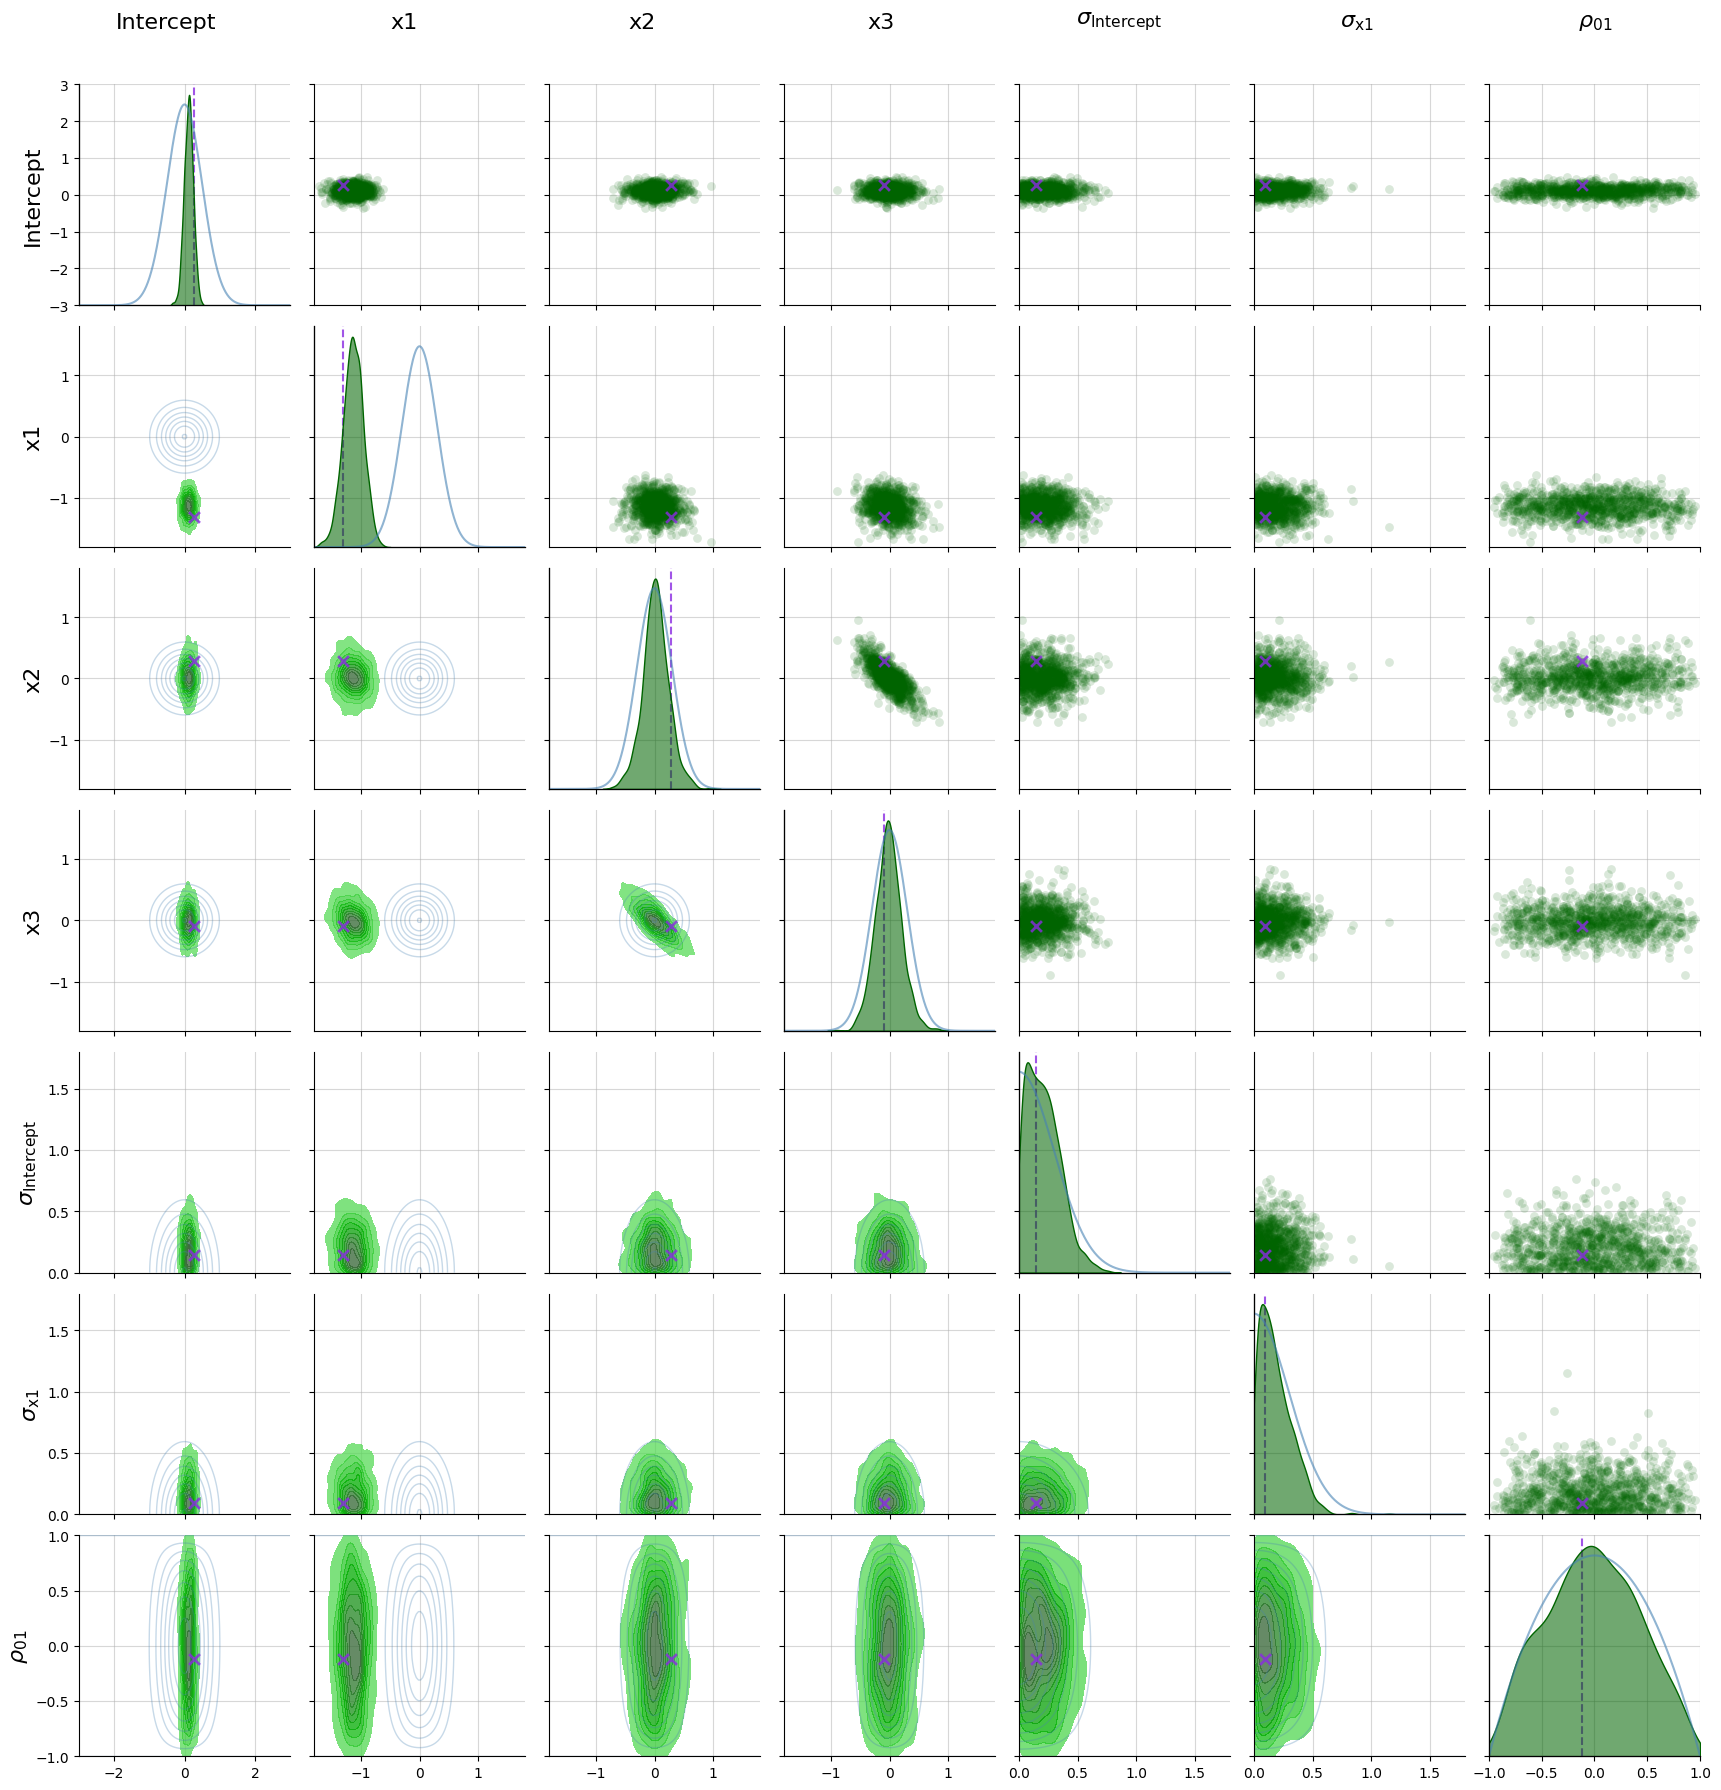

In [10]:
g = mb.plotParameters(result, index=2, with_prior=True, truth=truth)  # skeptical
plt.show()

### Summary

We estimated three GLMMs on the same dataset with the same formula but different priors.
Thanks to the amortised neural model, all three ran in a single batched forward pass.

The data are informative enough that the results are broadly similar: predictive AUC varies
only between 0.82 and 0.83.  The clearest prior effect is on X1 (true β ≈ −1.3): the
**skeptical** prior pulls the posterior mean toward zero (≈ −1.1 vs. ≈ −1.5 for default
and generative), with noticeably increased contraction and narrower credible intervals.